In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [3]:
png_path= r"C:\Users\arber\Desktop\georeferencer\georeferencer\LoFTR_map_georeferencer\output\kohlkamp.png"

In [23]:
import cv2
import numpy as np

img = cv2.imread(png_path)
hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)

# Rote Töne maskieren (zwei Bereiche im HSV-Farbraum)
mask1 = cv2.inRange(hsv, (0,  60, 60), (10,  255, 255))
mask2 = cv2.inRange(hsv, (160, 60, 60), (180, 255, 255))
red_mask = cv2.bitwise_or(mask1, mask2)

# Rote Flächen durch helles Grau ersetzen
result = img.copy()
result[red_mask > 0] = [210, 210, 210]

# Graustufen + CLAHE (Kontrastverbesserung)
gray = cv2.cvtColor(result, cv2.COLOR_BGR2GRAY)
clahe = cv2.createCLAHE(clipLimit=2.5, tileGridSize=(8,8))
gray = clahe.apply(gray)

# Bilateral Filter (Rauschreduktion ohne Kantenverlust)
gray = cv2.bilateralFilter(gray, d=9, sigmaColor=75, sigmaSpace=75)

# Optional: Schärfen
kernel = np.array([[0,-1,0],[-1,5,-1],[0,-1,0]])
gray = cv2.filter2D(gray, -1, kernel)

inverted = cv2.bitwise_not(gray)

# Kernel bestimmt wie stark/in welche Richtung aufgebläht wird
kernel = np.ones((1, 1), np.uint8)   # 3x3 = leicht dicker, 5x5 = deutlich dicker

dilated = cv2.dilate(inverted, kernel, iterations=1)  # iterations=2 für noch dicker

# Zurück invertieren: Linien wieder schwarz
result_thick = cv2.bitwise_not(dilated)

cv2.imwrite("bebauungsplan_dicke_linien.png", result_thick)


True

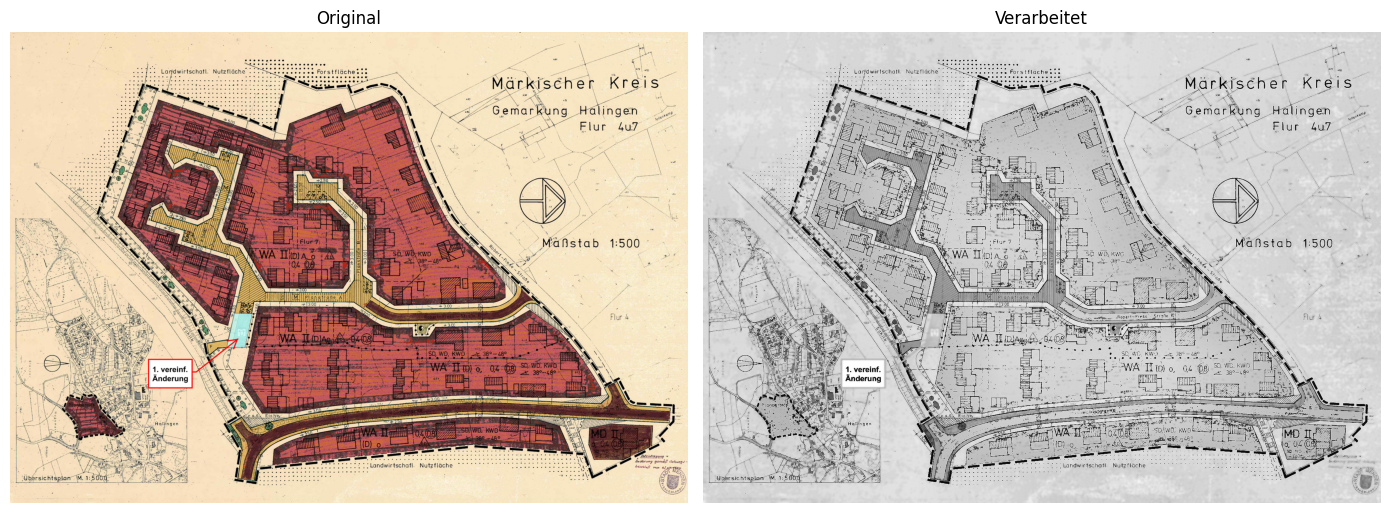

In [7]:
from matplotlib import pyplot as plt

plt.figure(figsize=(14, 10))

plt.subplot(1, 2, 1)
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title("Original")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(gray, cmap="gray")
plt.title("Verarbeitet")
plt.axis("off")

plt.tight_layout()
plt.show()

In [14]:
img_osm = cv2.imread(png_path)

# OSM: Straßen sind weiß/hellgrau → isolieren
gray_osm = cv2.cvtColor(img_osm, cv2.COLOR_BGR2GRAY)

# Helle Bereiche (Straßen) hervorheben
clahe = cv2.createCLAHE(clipLimit=2.5, tileGridSize=(8,8))
gray_osm = clahe.apply(gray_osm)

# Gebäude (beige) durch einheitliches Grau ersetzen
hsv_osm = cv2.cvtColor(img_osm, cv2.COLOR_BGR2HSV)
building_mask = cv2.inRange(hsv_osm, (15, 10, 150), (35, 60, 220))
gray_osm[building_mask > 0] = 140  # Gebäude einheitlich grau

# Gleiche Linienverdickung wie beim Bplan
inverted = cv2.bitwise_not(gray_osm)
kernel = np.ones((2,2), np.uint8)
dilated = cv2.dilate(inverted, kernel, iterations=1)
osm_processed = cv2.bitwise_not(dilated)

cv2.imwrite("osm_processed.png", osm_processed)

True